***1. Exploratory analysis of data and visualizations***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
df = pd.read_csv("train.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3512 entries, 0 to 3511
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Context   3512 non-null   object
 1   Response  3508 non-null   object
dtypes: object(2)
memory usage: 55.0+ KB


In [ ]:
print(df.isnull().sum())

Context     0
Response    4
dtype: int64


In [ ]:
df = df.dropna()

In [ ]:
df.describe()

,Context,Response
count,3508,3508
unique,995,2479
top,I have so many issues to address. I have a his...,"If you have only been to a couple of sessions,..."
freq,94,3


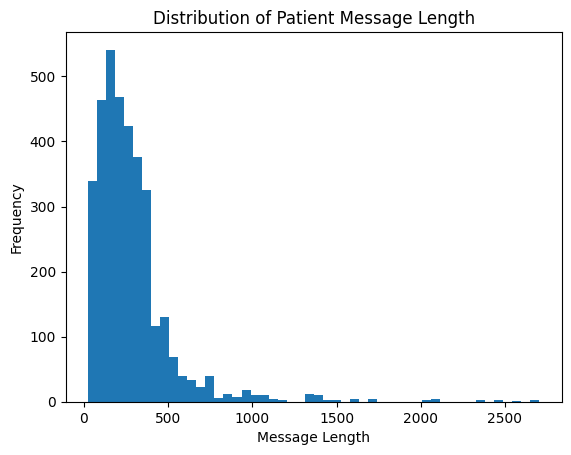

In [ ]:
df["length"] = df["Context"].apply(len)

plt.hist(df["length"], bins=50)
plt.title("Distribution of Patient Message Length")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

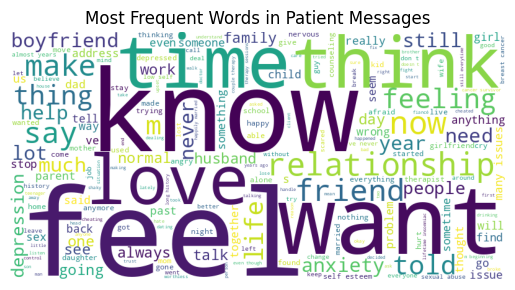

In [ ]:
text = " ".join(df["Context"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Patient Messages")
plt.show()

***2. Data preprocessing***

In [ ]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^\w\s]", "", text)

    tokens = word_tokenize(text)

    tokens = [w for w in tokens if w not in stop_words]

    return " ".join(tokens)

In [ ]:
df["clean_text"] = df["Context"].apply(clean_text)

print(df[["Context","clean_text"]].head())

                                             Context  \
0  I'm going through some things with my feelings...   
1  I'm going through some things with my feelings...   
2  I'm going through some things with my feelings...   
3  I'm going through some things with my feelings...   
4  I'm going through some things with my feelings...   

                                          clean_text  
0  im going things feelings barely sleep nothing ...  
1  im going things feelings barely sleep nothing ...  
2  im going things feelings barely sleep nothing ...  
3  im going things feelings barely sleep nothing ...  
4  im going things feelings barely sleep nothing ...  


***3. Training in the emotional classification model***

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_text"])

In [ ]:
emotion_patterns = {
    'anxiety': ['anxiety', 'anxious', 'worry', 'worried', 'nervous', 'panic', 'fear', 'scared', 'tense', 'stress', 'overwhelm', 'dread'],
    'sadness': ['sad', 'depressed', 'unhappy', 'grief', 'sorrow', 'down', 'cry', 'hopeless', 'lonely', 'hurt', 'pain', 'alone'],
    'angry': ['angry', 'anger', 'frustrated', 'mad', 'annoyed', 'rage', 'irritated', 'hate', 'upset', 'furious', 'pissed'],
    'stress': ['stress', 'overwhelmed', 'pressure', 'burnout', 'tension', 'exhausted', 'tired', 'busy', 'work', 'deadline'],
    'happiness': ['happy', 'glad', 'joy', 'excited', 'grateful', 'thankful', 'pleased', 'delighted', 'wonderful', 'great', 'good'],
    'fear': ['fear', 'afraid', 'terrified', 'frightened', 'horror', 'scary', 'terrible', 'awful', 'nightmare'],
    'apathy': ['bored', 'indifferent', 'numb', 'empty', 'nothing', 'whatever', 'pointless', 'meaningless', 'tired', 'whatever'],
    'confusion': ['confused', 'unsure', 'uncertain', 'doubt', 'puzzled', 'lost', 'understand', 'confusing', 'clear'],
    'solitude': ['alone', 'lonely', 'isolated', 'abandoned', 'deserted', 'nobody', 'no one', 'friends', 'social'],
    'hope': ['hope', 'hopeful', 'better', 'improve', 'recover', 'heal', 'progress', 'future', 'positive'],
    'guilt': ['guilt', 'guilty', 'blame', 'regret', 'sorry', 'apologize', 'mistake', 'wrong'],
    'shame': ['shame', 'embarrassed', 'humiliated', 'ashamed', 'awkward', 'stupid', 'foolish']
}

In [ ]:
def detect_emotion(text):
    for emotion, patterns in emotion_patterns.items():
        for pattern in patterns:
            if pattern in text:
                return emotion
    return "neutral"
df["emotion"] = df["clean_text"].apply(detect_emotion)

In [ ]:
y = df["emotion"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

emotion_model = LogisticRegression(max_iter=200)

emotion_model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

***4. Model evaluation***

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [ ]:
y_pred = emotion_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8817663817663818
              precision    recall  f1-score   support

       angry       0.93      0.84      0.88        63
     anxiety       0.92      0.97      0.94       174
      apathy       1.00      0.64      0.78        11
   confusion       1.00      0.72      0.84        18
        fear       1.00      0.68      0.81        19
       guilt       1.00      0.55      0.71        11
   happiness       1.00      0.63      0.78        30
        hope       1.00      0.67      0.80        15
     neutral       0.77      0.98      0.86       153
     sadness       0.87      0.95      0.91       131
       shame       1.00      0.92      0.96        13
    solitude       1.00      0.65      0.79        20
      stress       1.00      0.68      0.81        44

    accuracy                           0.88       702
   macro avg       0.96      0.76      0.84       702
weighted avg       0.90      0.88      0.88       702



In [ ]:
!pip install sentence-transformers

***5. Implementation of the complete hybrid system***

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
context_embeddings = embedding_model.encode(df["Context"].tolist())

In [ ]:
def retrieve_response(user_input):

    user_embedding = embedding_model.encode([user_input])

    similarity = cosine_similarity(user_embedding, context_embeddings)

    index = similarity.argmax()

    return df.iloc[index]["Response"]

In [ ]:
def mental_health_chatbot():

    user_input = input("Text from the Patient: ")
    clean = clean_text(user_input)
    vector = vectorizer.transform([clean])
    emotion = emotion_model.predict(vector)[0]
    response = retrieve_response(user_input)

    print("\nDetected Emotion:", emotion)
    print("\nEmpathetic Response:", response)
    print("\nThis system is an academic demonstration and does not replace professional mental health support.")

In [ ]:
mental_health_chatbot()


Text from the Patient: yesterday i had my first therapy session, i felt anxious 

Detected Emotion: anxiety

Empathetic Response: Hello. First, I am so sorry you are experiencing these feelings. They can be intense, I will do my best to offer some suggestions or thoughts that I hope will be helpful to you. There could be a number of things occurring. Therapy is a delicate, private decision and I would first like to commend you for the fact that you are not giving up, that you are working to figure this out, and make this work, it sounds like you are engaged and motivated to receive support from a professional, your continued  dedication and motivation will take you far. I would first start by asking if you have discussed this with your therapist, if you feel comfortable enough telling your therapist what is going on, maybe inform the therapist that  that you feel nervous and shaky. I am a firm believer in open communication between the client and therapist as this builds a healthy ther

In [ ]:
mental_health_chatbot()

Text from the Patient: yesterday i had my first therapy session, i felt sad and i started cry

Detected Emotion: sadness

Empathetic Response: It's more than just normal, it's expected! Quite honestly, there are a very few days where at least one client hasn't cried during therapy throughout the day. -IJP

This system is an academic demonstration and does not replace professional mental health support.


In [ ]:
mental_health_chatbot()

Text from the Patient: i am good

Detected Emotion: happiness

Empathetic Response: It seems like you may be experiencing depression symptoms, they could be the triggered by unexpected life changes, or building up throughout time.The important part is that you have identified them and wanting to change them.  The first step is to establish a self-care routine that will help you to feel centered and motivated: go for walks, or make any physical activity that you enjoy ( be kind to yourself, anything helps at this point), eat balanced, add whole grains and fibers to your diet, make a point to rest at night and avoid naps, practice a hobby that you love, or look for a new one that you are curious about. You mentioned that you feel unsettled in your soul: explore your spirituality, meditate about what makes your soul at peace, and find ways to practice that or surround yourself by those activities.If you find it difficult to begin, talk to your therapist to identify roadblocks and ways to 

***6. Ethical reflection on the use of AI in mental health***

AI can be a great help when we try to learn about new things, but when it comes to mental health and emotions, AI can pose risks by not fully understanding the emotions a patient is trying to express. Therefore, its use in this setting should be limited to psychologists and under specific parameters.